## Import Required Libraries

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import savemat, loadmat
from scipy.signal import find_peaks
import os

# Set plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 12

## Setup - Define File Paths and Motor Angles

In [83]:
# Setup - File paths and motor angles
filepath = '../data/fig4_beamforming_20221209_meas2/'

# Motor angles configuration (266 to 274 only)
motor_angles = np.arange(266, 275, 1)  # 266:1:274

# Generate file names
files = [f"{angle}deg.csv" for angle in motor_angles]
filenames = [os.path.join(filepath, f) for f in files]

print(f"Number of files: {len(files)}")
print(f"Motor angles: {motor_angles}")

Number of files: 9
Motor angles: [266 267 268 269 270 271 272 273 274]


## Define phaseCalc Function

This function calculates phase differences between channels using bandpass filtering and Hilbert transform.

In [84]:
from scipy.signal import butter, filtfilt, hilbert, sosfiltfilt, iirfilter

def bandpass_filter(data, lowcut, highcut, fs):
    """
    Apply bandpass filter to data using SOS format for numerical stability.
    Uses Chebyshev Type I filter similar to MATLAB's bandpass with Steepness=0.9
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    
    # Use SOS (second-order sections) for numerical stability with narrow bands
    # Chebyshev Type I filter with 0.5 dB passband ripple, order 6 for sharp transition
    sos = iirfilter(6, [low, high], btype='band', ftype='cheby1', rp=0.5, output='sos')
    return sosfiltfilt(sos, data)

def phaseCalc(filename):
    """
    Calculate phase differences and amplitudes from measurement file.
    
    Parameters:
    -----------
    filename : str
        Path to CSV file containing measurement data
        
    Returns:
    --------
    phaseDiffs : ndarray
        Phase differences between channels (in degrees)
    phaseStds : ndarray
        Standard deviations of phase differences (in degrees)
    amps : ndarray
        Amplitude for each channel
    """
    # Read data using Python engine to handle problematic files
    M = pd.read_csv(filename, header=None, engine='python').values
    M = M[:20000, :]  # Limit to first 20k samples
    
    # Sampling parameters
    N = 1  # undersampling factor
    Fsample = 100e6 / N
    Frac = 1
    start = 0
    
    # Time vector
    num_samples = int(len(M) / Frac / N)
    t = np.arange(1, num_samples + 1) / Fsample
    dt = t[1] - t[0]
    Fs = 1 / dt
    
    # Filter parameters
    Filter_BW = 5e3  # 10 kHz bandwidth
    Center_Freq = 1000e3  # 1 MHz center frequency
    BPF_L = Center_Freq - Filter_BW / 2
    BPF_H = Center_Freq + Filter_BW / 2
    
    # Extract channels (MATLAB uses 1-based indexing)
    num_rows = int(len(M) / Frac)
    dataI1 = M[start:start + num_rows, 1]  # Column 2 in MATLAB
    dataI2 = M[start:start + num_rows, 7]  # Column 8 in MATLAB
    dataI3 = M[start:start + num_rows, 2]  # Column 3 in MATLAB
    dataI4 = M[start:start + num_rows, 3]  # Column 4 in MATLAB
    dataI5 = M[start:start + num_rows, 4]  # Column 5 in MATLAB
    dataI6 = M[start:start + num_rows, 5]  # Column 6 in MATLAB
    
    # Create signals
    Signal1 = dataI1
    Signal2 = dataI2
    Signal3 = dataI3
    Signal4 = 2.5 * dataI4
    Signal5 = dataI5
    Signal6 = dataI6
    
    # Apply bandpass filter
    SigI1_Filt = bandpass_filter(Signal1, BPF_L, BPF_H, Fs)
    SigI2_Filt = bandpass_filter(Signal2, BPF_L, BPF_H, Fs)
    SigI3_Filt = bandpass_filter(Signal3, BPF_L, BPF_H, Fs)
    SigI4_Filt = bandpass_filter(Signal4, BPF_L, BPF_H, Fs)
    SigI5_Filt = bandpass_filter(Signal5, BPF_L, BPF_H, Fs)
    SigI6_Filt = bandpass_filter(Signal6, BPF_L, BPF_H, Fs)
    
    # Hilbert transform for phase extraction
    HT_CH1 = hilbert(SigI1_Filt)
    HT_CH2 = hilbert(SigI2_Filt)
    HT_CH3 = hilbert(SigI3_Filt)
    HT_CH4 = hilbert(SigI4_Filt)
    HT_CH5 = hilbert(SigI5_Filt)
    HT_CH6 = hilbert(SigI6_Filt)
    
    # Calculate and unwrap phases
    phase_CH1 = np.unwrap(np.arctan2(np.imag(HT_CH1), np.real(HT_CH1)))
    phase_CH2 = np.unwrap(np.arctan2(np.imag(HT_CH2), np.real(HT_CH2)))
    phase_CH3 = np.unwrap(np.arctan2(np.imag(HT_CH3), np.real(HT_CH3)))
    phase_CH4 = np.unwrap(np.arctan2(np.imag(HT_CH4), np.real(HT_CH4)))
    phase_CH5 = np.unwrap(np.arctan2(np.imag(HT_CH5), np.real(HT_CH5)))
    phase_CH6 = np.unwrap(np.arctan2(np.imag(HT_CH6), np.real(HT_CH6)))
    
    # Calculate amplitudes
    amp2_1 = np.sqrt(np.imag(HT_CH1)**2 + np.real(HT_CH1)**2)
    amp2_2 = np.sqrt(np.imag(HT_CH2)**2 + np.real(HT_CH2)**2)
    amp2_3 = np.sqrt(np.imag(HT_CH3)**2 + np.real(HT_CH3)**2)
    amp2_4 = np.sqrt(np.imag(HT_CH4)**2 + np.real(HT_CH4)**2)
    amp2_5 = np.sqrt(np.imag(HT_CH5)**2 + np.real(HT_CH5)**2)
    amp2_6 = np.sqrt(np.imag(HT_CH6)**2 + np.real(HT_CH6)**2)
    
    # Filter amplitudes - remove edge effects
    t_max = np.max(t)
    mask = (t > 50e-6) & (t < (t_max - 50e-6))
    
    amp_1 = np.median(amp2_1[mask])
    amp_2 = np.median(amp2_2[mask])
    amp_3 = np.median(amp2_3[mask])
    amp_4 = np.median(amp2_4[mask])
    amp_5 = np.median(amp2_5[mask])
    amp_6 = np.median(amp2_6[mask])
    
    # Calculate phase differences
    phiO = np.pi / 2
    PhaseDiff1 = np.mod(phase_CH6 - phase_CH5 + phiO, 2*np.pi) - phiO
    PhaseDiff2 = np.mod(phase_CH6 - phase_CH4 + phiO, 2*np.pi) - phiO
    PhaseDiff3 = np.mod(phase_CH6 - phase_CH3 + phiO, 2*np.pi) - phiO
    PhaseDiff4 = np.mod(phase_CH6 - phase_CH2 + phiO, 2*np.pi) - phiO
    PhaseDiff5 = np.mod(phase_CH6 - phase_CH1 + phiO, 2*np.pi) - phiO
    
    # Apply mask to phase differences
    PhaseDiff1 = PhaseDiff1[mask]
    PhaseDiff2 = PhaseDiff2[mask]
    PhaseDiff3 = PhaseDiff3[mask]
    PhaseDiff4 = PhaseDiff4[mask]
    PhaseDiff5 = PhaseDiff5[mask]
    
    # Convert to degrees and calculate statistics directly (no amplitude weighting)
    phase_deg1 = PhaseDiff1 * 180 / np.pi
    phase_deg2 = PhaseDiff2 * 180 / np.pi
    phase_deg3 = PhaseDiff3 * 180 / np.pi
    phase_deg4 = PhaseDiff4 * 180 / np.pi
    phase_deg5 = PhaseDiff5 * 180 / np.pi
    
    # Calculate median and std for each phase difference
    phaseDifff1 = np.median(phase_deg1)
    phaseDifff2 = np.median(phase_deg2)
    phaseDifff3 = np.median(phase_deg3)
    phaseDifff4 = np.median(phase_deg4)
    phaseDifff5 = np.median(phase_deg5)
    
    phaseStd1 = np.std(phase_deg1)
    phaseStd2 = np.std(phase_deg2)
    phaseStd3 = np.std(phase_deg3)
    phaseStd4 = np.std(phase_deg4)
    phaseStd5 = np.std(phase_deg5)
    
    # Quality check
    std_th = 10
    for i, (std_val, median_val, label) in enumerate(zip(
            [phaseStd1, phaseStd2, phaseStd3, phaseStd4, phaseStd5],
            [phaseDifff1, phaseDifff2, phaseDifff3, phaseDifff4, phaseDifff5],
            ['G6G7', 'G6G8', 'G6G9', 'G6G10', 'G6G11'])):
        if std_val < std_th:
            print(f'Median{i+1} = {median_val:.2f}, Std = {std_val:.2f}')
        else:
            print(f'BAD DATA {label}: stddev = {std_val:.2f}')
                
    phaseDiffs = np.array([phaseDifff1, phaseDifff2, phaseDifff3, phaseDifff4, phaseDifff5])
    phaseStds = np.array([phaseStd1, phaseStd2, phaseStd3, phaseStd4, phaseStd5])
    amps = np.array([amp_1, amp_2, amp_3, amp_4, amp_5, amp_6])
    
    return phaseDiffs, phaseStds, amps

## Phase Processing

Process all measurement files to extract phase differences and amplitudes.

In [85]:
# Process all files to get phase differences, stds, and amplitudes
phaseDiffs_list = []
phaseStds_list = []
amps_list = []

for i, filename in enumerate(filenames):
    print(f"Processing file {i+1}/{len(filenames)}: {files[i]}")
    try:
        phaseDiff, phaseStd, amp = phaseCalc(filename)
        phaseDiffs_list.append(phaseDiff)
        phaseStds_list.append(phaseStd)
        amps_list.append(amp)
    except Exception as e:
        print(f"Error processing {files[i]}: {e}")
        continue

phaseDiffs = np.array(phaseDiffs_list)
phaseStds = np.array(phaseStds_list)
amps = np.array(amps_list)

print(f"\nProcessed {len(phaseDiffs)} files successfully")
print(f"Phase differences shape: {phaseDiffs.shape}")
print(f"Phase stds shape: {phaseStds.shape}")
print(f"Amplitudes shape: {amps.shape}")

Processing file 1/9: 266deg.csv
Median1 = 69.01, Std = 7.37
Median2 = 184.18, Std = 0.55
Median3 = 48.06, Std = 5.66
Median4 = 171.11, Std = 1.17
Median5 = -40.95, Std = 5.16
Processing file 2/9: 267deg.csv
Median1 = 122.55, Std = 6.60
BAD DATA G6G8: stddev = 72.55
Median3 = 186.93, Std = 0.90
Median4 = 1.57, Std = 0.20
Median5 = 169.62, Std = 1.34
Processing file 3/9: 268deg.csv
Median1 = 173.54, Std = 1.36
Median2 = 3.54, Std = 0.73
BAD DATA G6G9: stddev = 16.70
Median4 = 164.86, Std = 2.98
Median5 = 31.16, Std = 4.99
Processing file 4/9: 269deg.csv
BAD DATA G6G7: stddev = 15.64
Median2 = 82.32, Std = 8.11
Median3 = 80.02, Std = 8.11
BAD DATA G6G10: stddev = 13.67
BAD DATA G6G11: stddev = 29.71
Processing file 5/9: 270deg.csv
BAD DATA G6G7: stddev = 98.77
Median2 = 181.01, Std = 0.16
Median3 = 218.88, Std = 6.71
Median4 = 138.42, Std = 6.27
Median5 = 92.67, Std = 8.06
Processing file 6/9: 271deg.csv
BAD DATA G6G7: stddev = 44.36
BAD DATA G6G8: stddev = 65.24
Median3 = -20.60, Std = 2

## Organize and Save Data

In [86]:
# Organize data
N_GC = 6  # Number of grating couplers
N_angles = len(motor_angles)

# Create ordered array - first column is zeros, rest is phase differences
ordered = np.zeros((len(motor_angles), N_GC))
ordered[:, 1:N_GC] = phaseDiffs

# Create stds array - first column is zeros (reference channel has no error)
ordered_stds = np.zeros((len(motor_angles), N_GC))
ordered_stds[:, 1:N_GC] = phaseStds

# # Save to .mat file (for MATLAB compatibility)
# savemat('20221214_10us.mat', {'ordered': ordered})
# print("Data saved to 20221214_10us.mat")

## Channel Amplitudes Visualization

Calculating channel amplitudes


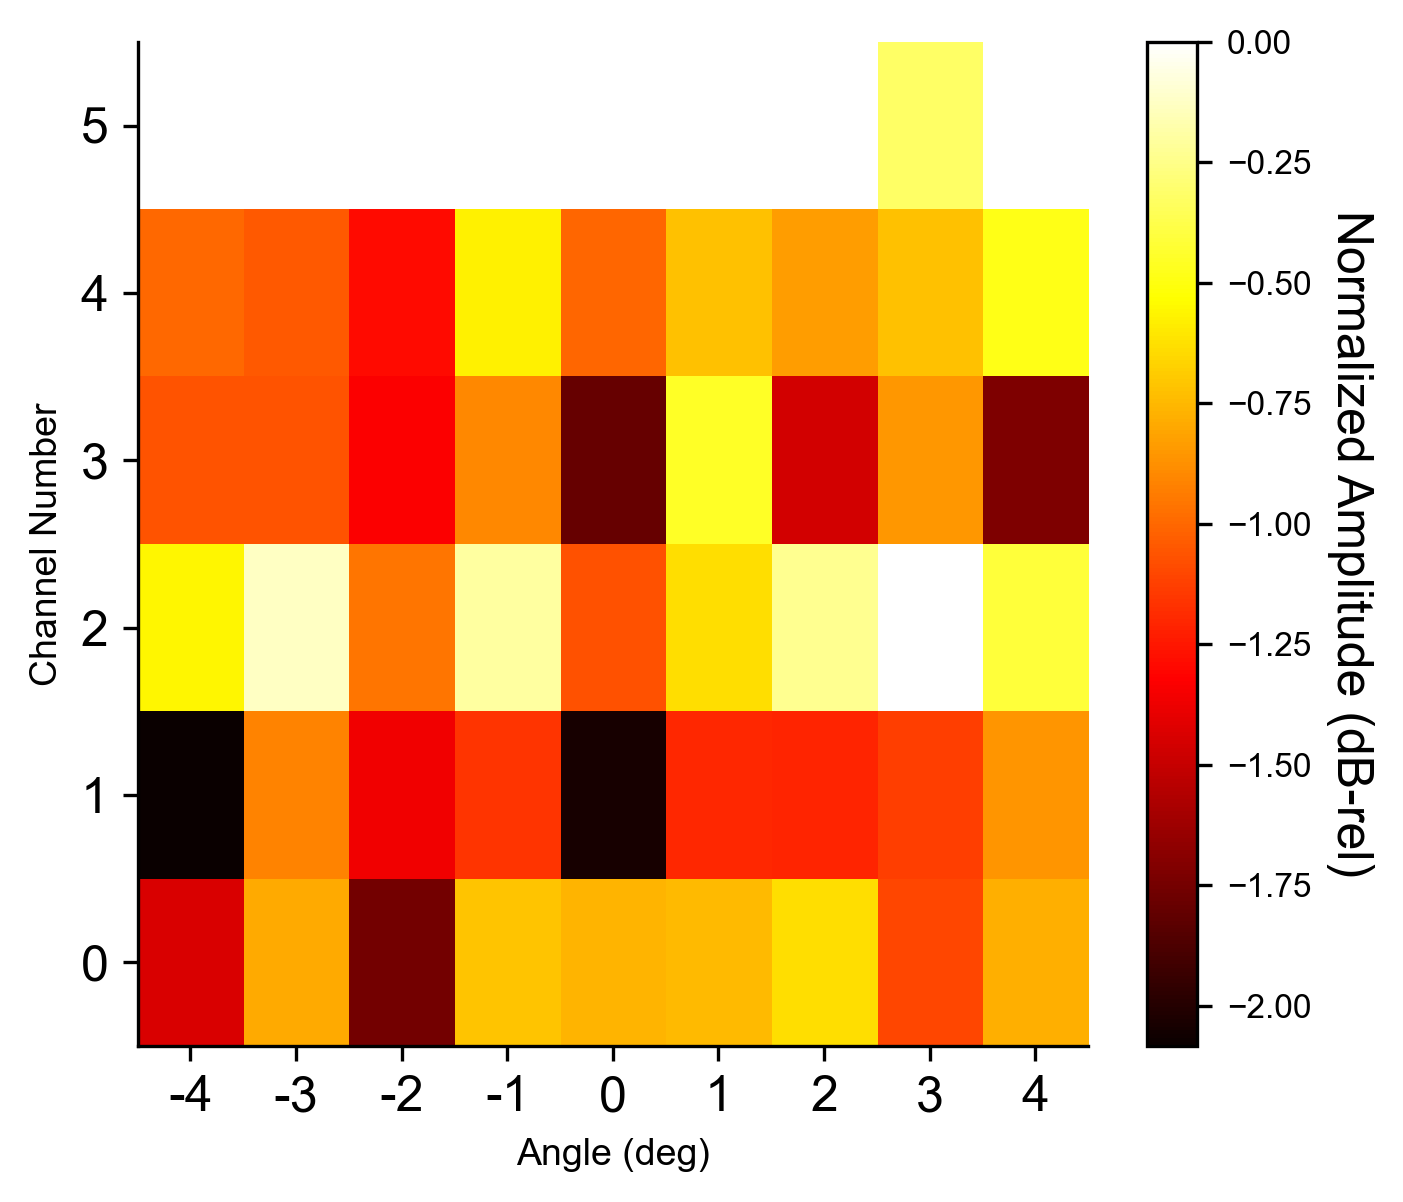

In [87]:
print('Calculating channel amplitudes')

# Normalize amplitudes
amps2 = amps / np.max(amps, axis=1, keepdims=True)

# Create figure
fig, ax = plt.subplots(figsize=(350/72, 300/72))

# Plot heatmap
im = ax.imshow(10 * np.log10(amps2.T), aspect='auto', cmap='hot', origin='lower')
cb = plt.colorbar(im, ax=ax)

ax.set_xlabel('Angle (deg)')
ax.set_ylabel('Channel Number')
ax.set_xlim([0.5 - 1, 9.5 - 1])  # Adjusted for 0-indexing
ax.set_ylim([0.5 - 1, 6.5 - 1])

# Set tick labels
fon = 12
ax.set_xticks(np.arange(9))
ax.set_xticklabels(['-4', '-3', '-2', '-1', '0', '1', '2', '3', '4'])
cb.set_label('Normalized Amplitude (dB-rel)', fontsize=fon, rotation=270, labelpad=15)
ax.tick_params(labelsize=fon)

plt.tight_layout()
plt.show()

## Channel Phases - Apply Phase Wrapping

In [88]:
print('Calculating channel phases')

ref = 4  # Reference index (0-based, corresponds to 5 in MATLAB)
angles = motor_angles.copy()

# Unwrap phases along columns (each channel separately) - axis=0 matches MATLAB behavior
ordered2 = np.unwrap(ordered / 180 * np.pi, axis=0)

# Calculate phase differences relative to reference
GC6 = (ordered2[:, 0] - ordered2[ref, 0]) / np.pi * 180
GC7 = (ordered2[:, 1] - ordered2[ref, 1]) / np.pi * 180
GC8 = (ordered2[:, 2] - ordered2[ref, 2]) / np.pi * 180
GC9 = (ordered2[:, 3] - ordered2[ref, 3]) / np.pi * 180
GC10 = (ordered2[:, 4] - ordered2[ref, 4]) / np.pi * 180
GC11 = (ordered2[:, 5] - ordered2[ref, 5]) / np.pi * 180

# Phase corrections (as in original MATLAB code)
GC10[0] = GC10[0] - 360
GC10[0:4] = GC10[0:4] - 360
GC10[6:] = GC10[6:] + 360
GC10[0:4] = GC10[0:4] + 360
GC10[8] = GC10[8] + 360

GC11[0] = GC11[0] - 360 * 4
GC11[1] = GC11[1] - 360 * 3
GC11[2] = GC11[2] - 360 * 2
GC11[3] = GC11[3] - 360 * 1
GC11[5] = GC11[5] + 360 * 1
GC11[6] = GC11[6] + 360 * 2
GC11[7] = GC11[7] + 360 * 3
GC11[8] = GC11[8] + 360 * 4
if len(GC11) > 9:
    GC11[9] = GC11[9] + 360 * 5
if len(GC11) > 10:
    GC11[10] = GC11[10] + 360 * 6
if len(GC11) > 11:
    GC11[11] = GC11[11] + 360 * 6
if len(GC11) > 12:
    GC11[12] = GC11[12] + 360 * 7

ordered2 = np.column_stack([GC6, GC7, GC8, GC9, GC10, GC11])
angles = angles - angles[ref]

print(f"Reference angle index: {ref}")
print(f"Angle range: {angles.min()} to {angles.max()} degrees")

Calculating channel phases
Reference angle index: 4
Angle range: -4 to 4 degrees


## Visualize Channel Phases

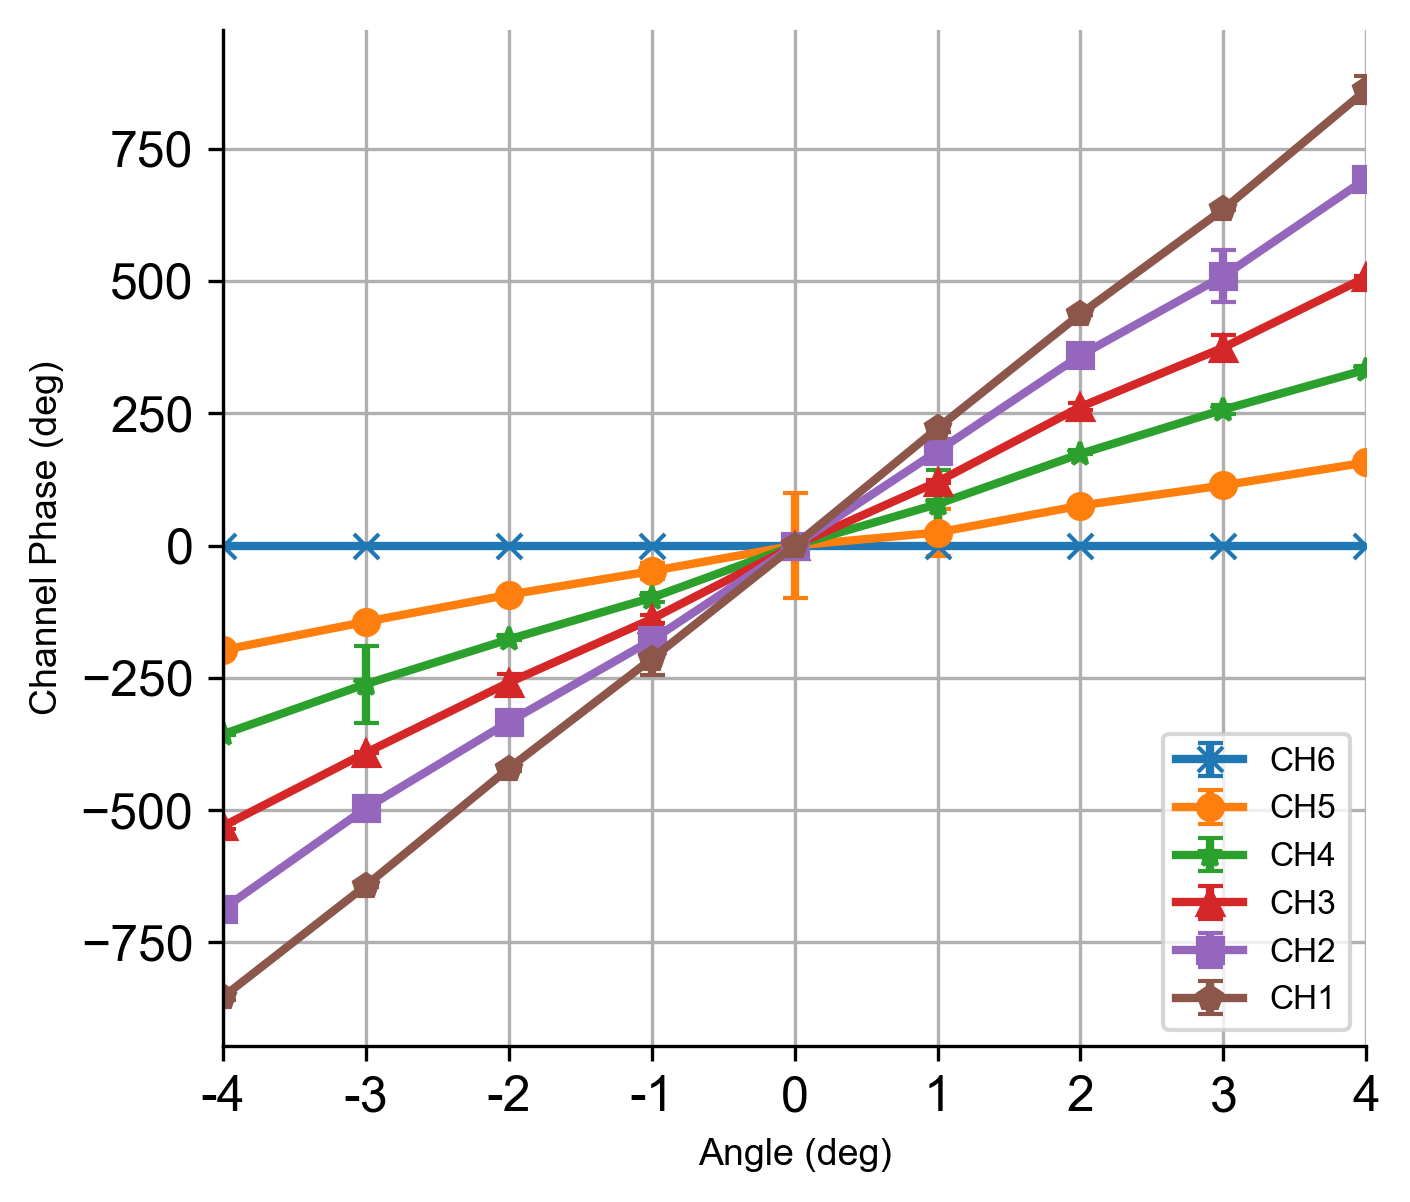

In [89]:
# Plot channel phases with error bars
fig, ax = plt.subplots(figsize=(350/72, 300/72))

l = 2  # Line width
markers = ['x', 'o', '*', '^', 's', 'p']
colors = plt.cm.tab10(np.arange(6))
labels = ['CH6', 'CH5', 'CH4', 'CH3', 'CH2', 'CH1']
GC_data = [GC6, GC7, GC8, GC9, GC10, GC11]

# Get stds for each channel (stds don't need phase correction, just use raw values)
GC_stds = [ordered_stds[:, i] for i in range(6)]

for i, (data, std, marker, color, label) in enumerate(zip(GC_data, GC_stds, markers, colors, labels)):
    ax.errorbar(angles, data, yerr=std, fmt='-' + marker, color=color, linewidth=l, 
                label=label, capsize=3, capthick=1, markersize=6)

ax.set_xlabel('Angle (deg)')
ax.set_ylabel('Channel Phase (deg)')
ax.set_xlim([-4, 4])
ax.tick_params(labelsize=fon)
ax.set_xticks(np.arange(-4, 5))
ax.set_xticklabels(['-4', '-3', '-2', '-1', '0', '1', '2', '3', '4'])
ax.legend(fontsize=8, loc='lower right')
ax.grid(True)
ax.set_facecolor('white')

plt.tight_layout()
plt.show()

In [90]:
# Plot phase histogram for CH1 at angle 274 deg
angle_idx = 8  # 274 deg = motor_angles[8] (266 + 8)
filename = filenames[angle_idx]
print(f"Processing histogram for angle: {motor_angles[angle_idx]} deg (file: {files[angle_idx]})")

# Load and process data for this angle
M = pd.read_csv(filename, header=None, engine='python').values
M = M[:20000, :]

# Sampling parameters
Fsample = 100e6
num_samples = len(M)
t = np.arange(1, num_samples + 1) / Fsample
Fs = Fsample

# Filter parameters
Filter_BW = 10e3
Center_Freq = 1000e3
BPF_L = Center_Freq - Filter_BW / 2
BPF_H = Center_Freq + Filter_BW / 2

# Extract CH1 and CH6 (reference)
dataI1 = M[:, 1]  # CH1
dataI6 = M[:, 5]  # CH6

Signal1 = dataI1
Signal6 = dataI6

# Apply bandpass filter
SigI1_Filt = bandpass_filter(Signal1, BPF_L, BPF_H, Fs)
SigI6_Filt = bandpass_filter(Signal6, BPF_L, BPF_H, Fs)

# Hilbert transform
HT_CH1 = hilbert(SigI1_Filt)
HT_CH6 = hilbert(SigI6_Filt)

# Phase extraction and unwrapping
phase_CH1 = np.unwrap(np.arctan2(np.imag(HT_CH1), np.real(HT_CH1)))
phase_CH6 = np.unwrap(np.arctan2(np.imag(HT_CH6), np.real(HT_CH6)))

# Mask for edge effects
t_max = np.max(t)
mask = (t > 50e-6) & (t < (t_max - 50e-6))

# Calculate phase difference (CH6 is reference)
phiO = np.pi / 2
PhaseDiff_CH1 = (np.mod(phase_CH6 - phase_CH1 + phiO, 2*np.pi) - phiO)[mask] * 180 / np.pi


Processing histogram for angle: 274 deg (file: 274deg.csv)


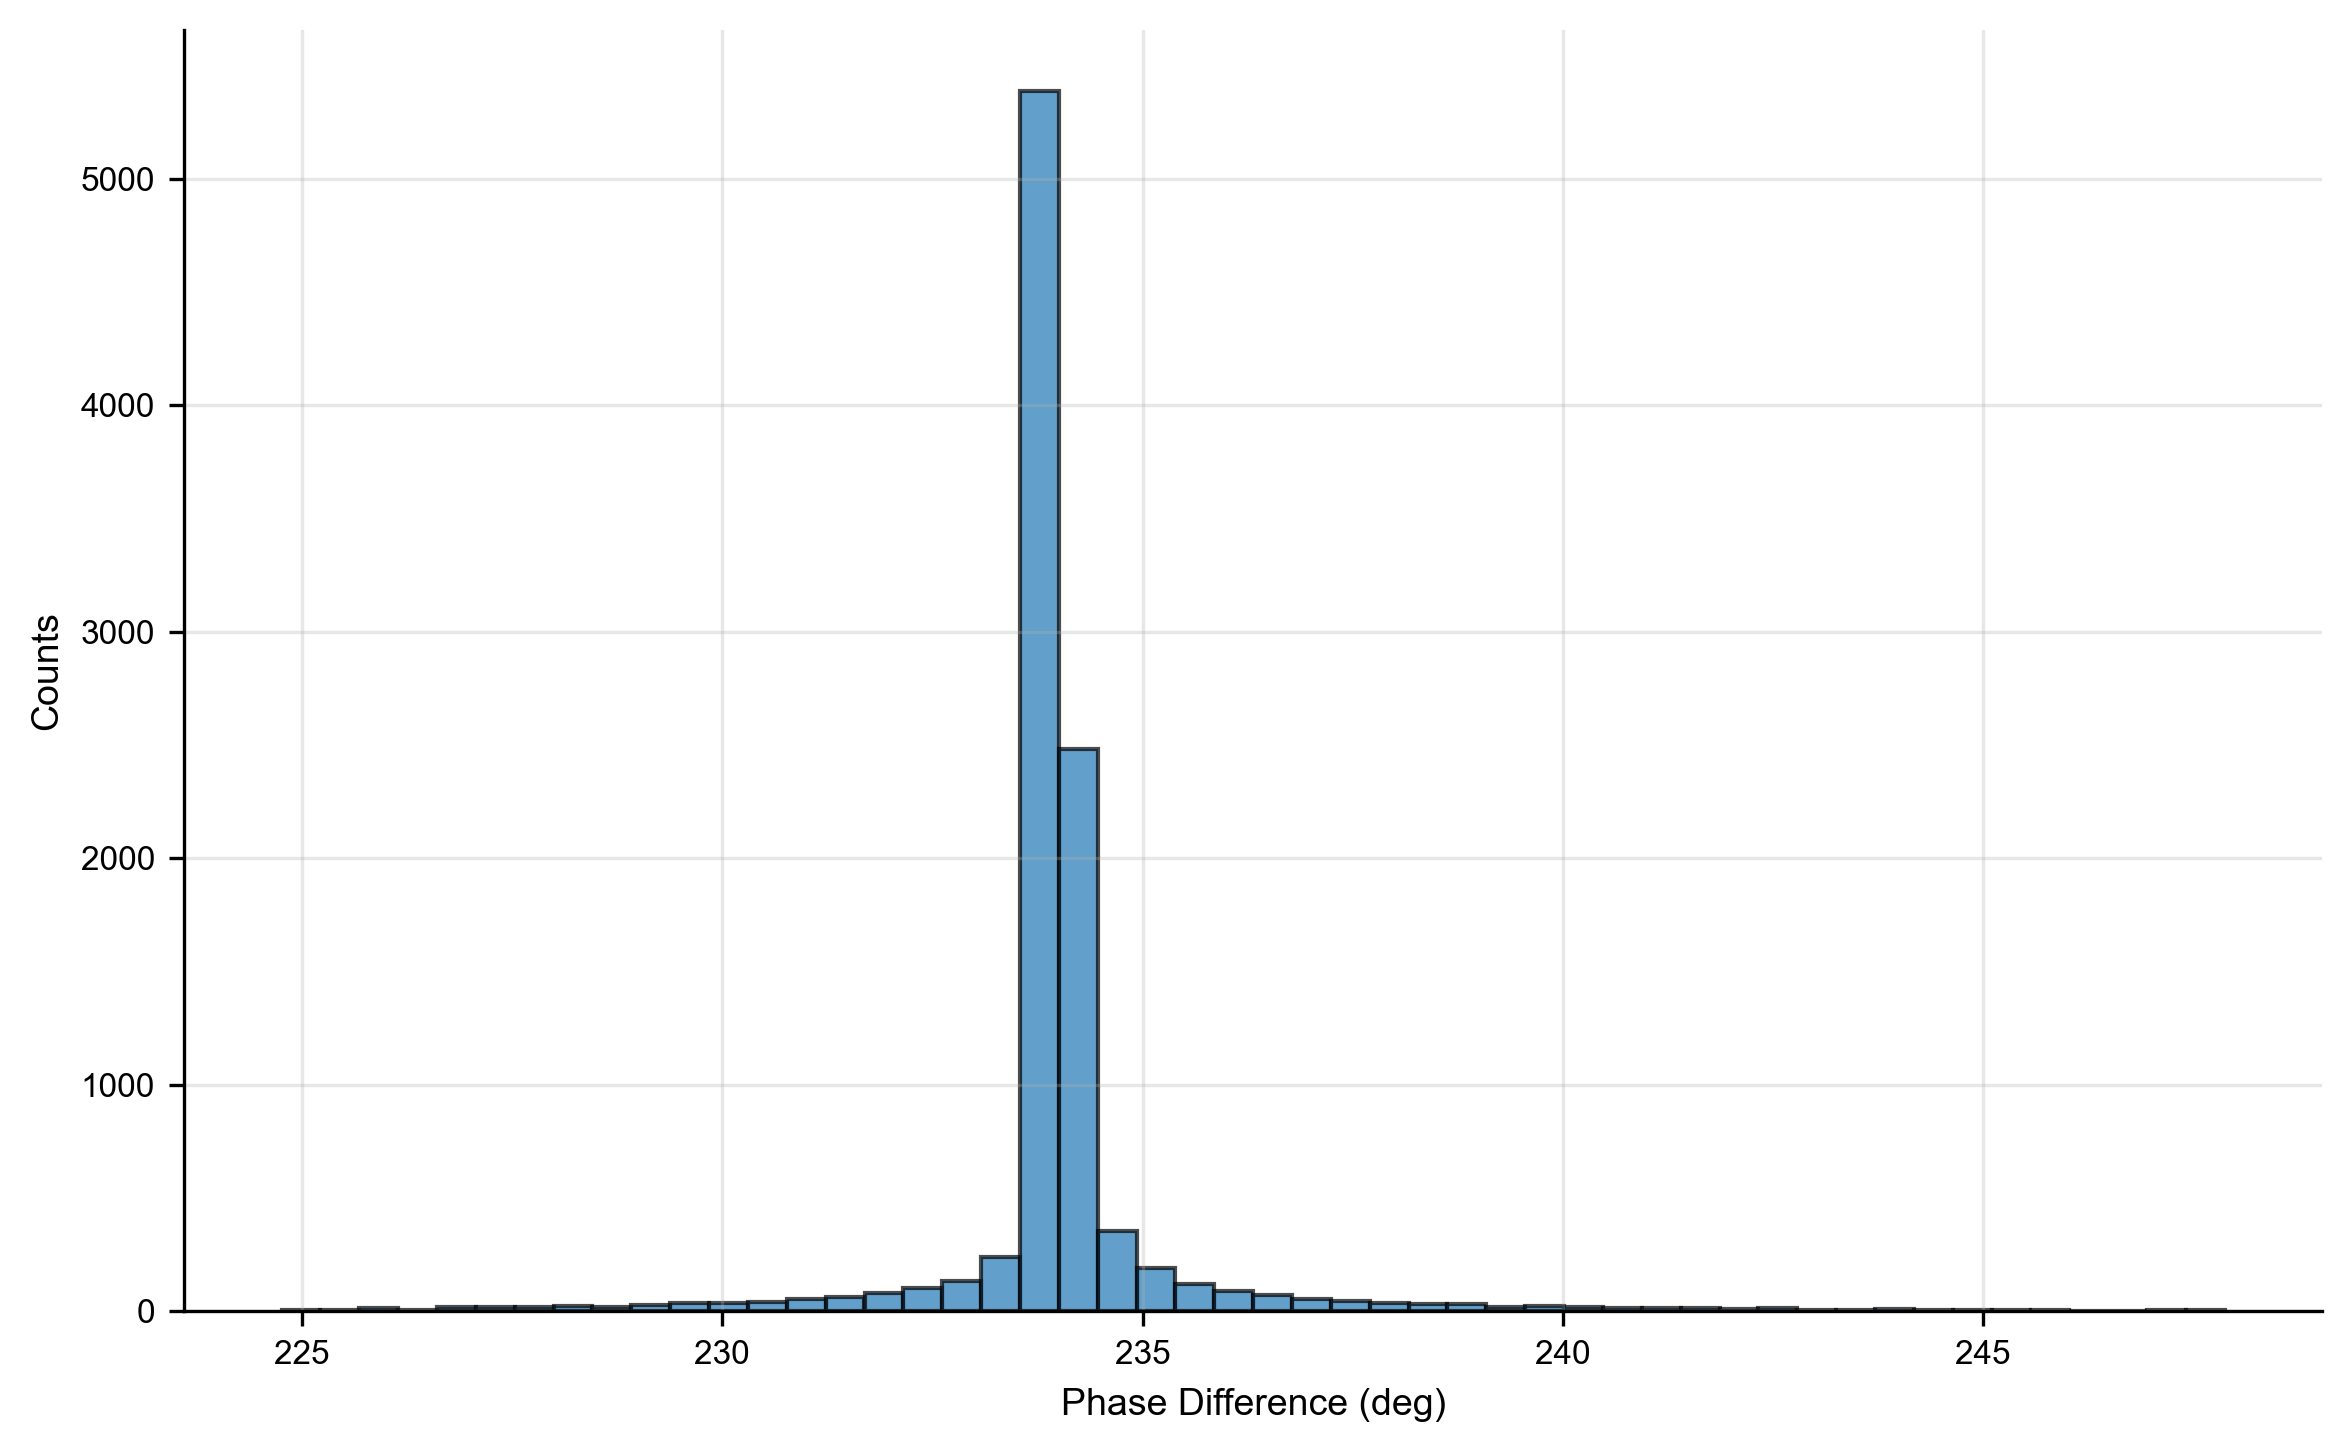

In [91]:

# Plot histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(PhaseDiff_CH1, bins=50, edgecolor='black', alpha=0.7, color=plt.cm.tab10(0))
ax.set_xlabel('Phase Difference (deg)')
ax.set_ylabel('Counts')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Reconstructed Antenna Array Pattern

Calculate and visualize the array factor pattern based on measured phase values.

In [92]:
print('Reconstructing pattern')

# Physical parameters
wavelength = 1555.23e-9  # meters (lambda)
d = 10.85e-6  # element spacing in meters
kd = 2 * np.pi / wavelength * d

# Angle range for pattern calculation
thetas = np.linspace(-17, 17, 10000)

# Reference phase subtraction
ref_phase = ordered[ref, :]
ordered_ref = ordered.copy()
for i in range(N_angles):
    ordered_ref[i, :] = ordered_ref[i, :] - ref_phase

# Configuration
ma_all = np.arange(0, 8)  # Which angles to analyze (0-indexed)
gc_all = np.array([5, 4, 3, 2, 1, 0])  # Grating coupler indices

print(f"Wavelength: {wavelength*1e9:.2f} nm")
print(f"Element spacing: {d*1e6:.2f} µm")
print(f"kd: {kd:.4f}")

Reconstructing pattern
Wavelength: 1555.23 nm
Element spacing: 10.85 µm
kd: 43.8344


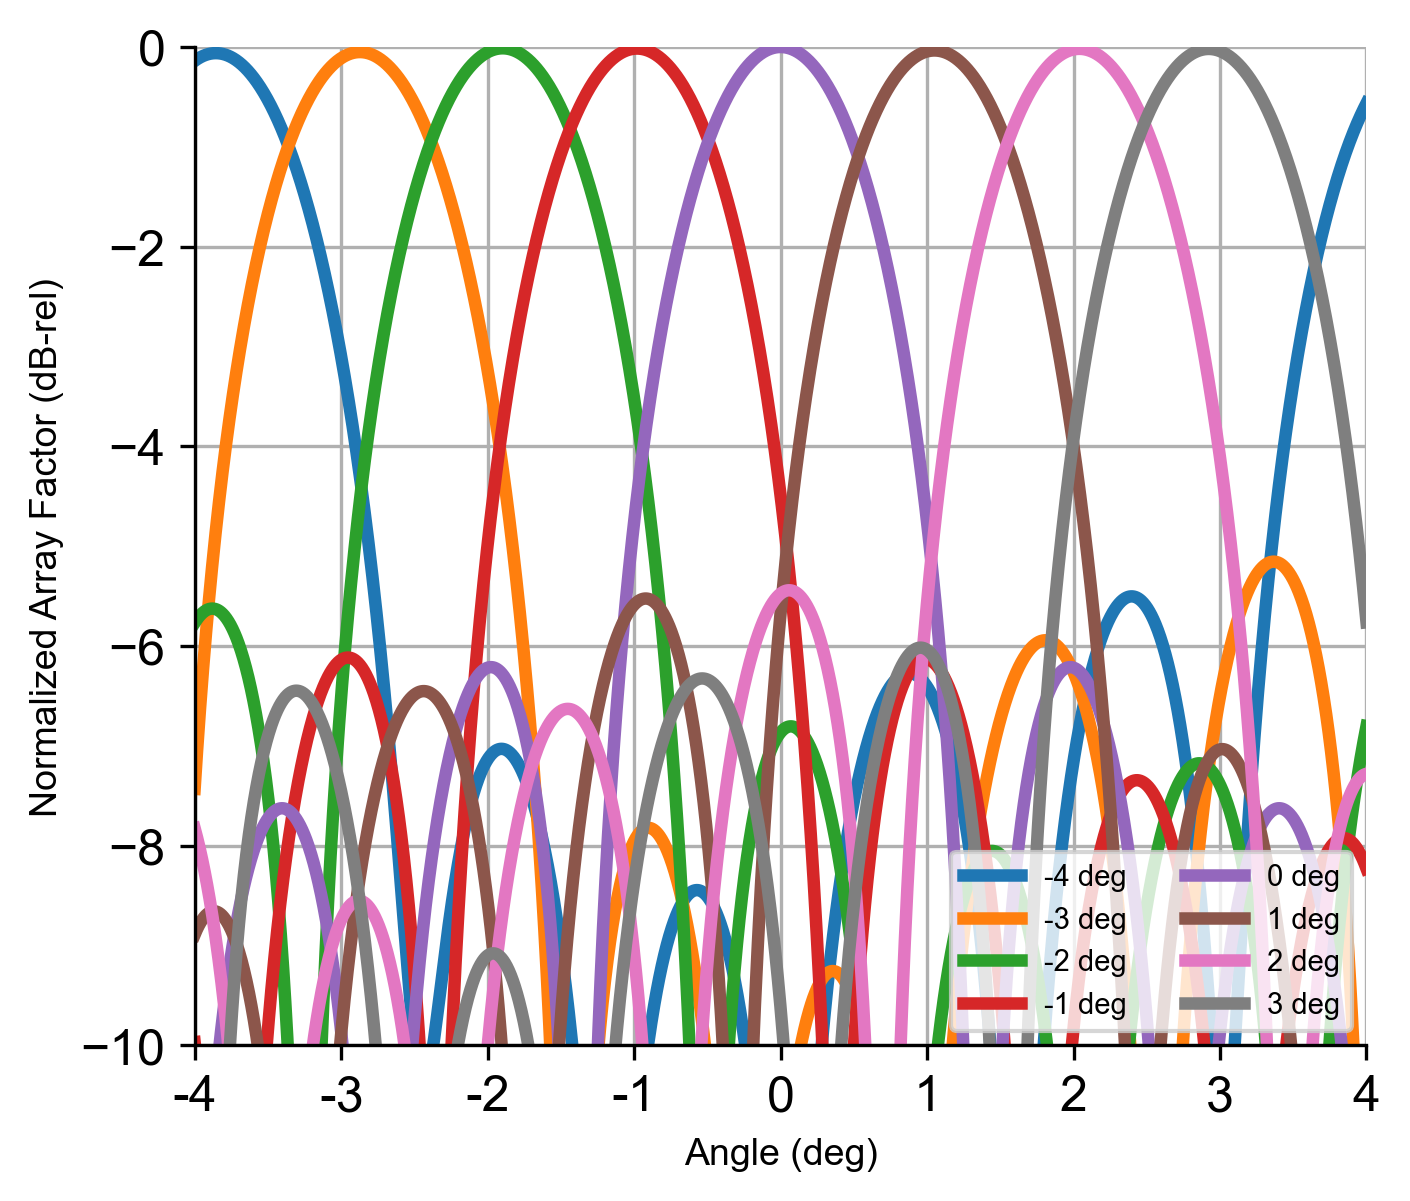


Mean FOV: 8.30 degrees
Mean Beamwidth: 1.67 degrees


In [93]:
# Calculate array factors
AFs = []
legend_labels = []

for ma_idx, ma in enumerate(ma_all):
    if ma >= len(ordered_ref):
        continue
    AF = np.zeros(len(thetas), dtype=complex)
    
    for gc_idx, gc in enumerate(gc_all):
        gc_phase = ordered_ref[ma, gc]
        # Calculate array factor contribution from each element
        effect = np.exp(1j * np.deg2rad(gc_phase)) * np.exp(1j * gc_idx * kd * np.sin(np.deg2rad(thetas)))
        AF = AF + effect
    
    AFs.append(AF)
    legend_labels.append(f'{angles[ma]} deg')

AFs = np.array(AFs)

# Normalize and convert to dB
abs_AFs = np.abs(AFs)
norm_AFs = abs_AFs / np.max(abs_AFs)
log_AFs = 10 * np.log10(norm_AFs)

# Calculate FOV and beamwidth metrics
fovs = []
bws = []

fig, ax = plt.subplots(figsize=(350/72, 300/72))

for ma_idx in range(len(AFs)):
    ax.plot(thetas, log_AFs[ma_idx, :], linewidth=3, label=legend_labels[ma_idx])
    
    # Find peaks for FOV calculation
    peaks, _ = find_peaks(norm_AFs[ma_idx, :], prominence=0.3)
    if len(peaks) >= 2:
        fov = abs(thetas[peaks[0]] - thetas[peaks[1]])
        fovs.append(fov)
        
        # Calculate beamwidth
        dif = round(abs(peaks[0] - peaks[1]) / 2)
        if peaks[1] - dif >= 0 and peaks[1] + dif < len(log_AFs[ma_idx]):
            pow_beam = log_AFs[ma_idx, peaks[1]-dif:peaks[1]+dif+1]
            th_beam = thetas[peaks[1]-dif:peaks[1]+dif+1]
            
            # Find -3dB points
            sorted_idx = np.argsort(np.abs(pow_beam + 3))
            i = 1
            bw = abs(th_beam[sorted_idx[i]] - th_beam[sorted_idx[0]])
            while bw < 1 and i < len(sorted_idx) - 1:
                i += 1
                bw = abs(th_beam[sorted_idx[i]] - th_beam[sorted_idx[0]])
            bws.append(bw)

ax.set_xlim([-4, 4])
ax.set_ylim([-10, 0])

fon = 12
ax.set_xlabel('Angle (deg)')
ax.set_ylabel('Normalized Array Factor (dB-rel)')
ax.set_xticks(np.arange(-4, 5))
ax.set_xticklabels(['-4', '-3', '-2', '-1', '0', '1', '2', '3', '4'])
ax.legend(ncol=2, loc='lower right')
ax.tick_params(labelsize=fon)
ax.grid(True)

plt.tight_layout()
plt.show()

# Print metrics
if len(fovs) > 0:
    print(f"\nMean FOV: {np.mean(fovs):.2f} degrees")
if len(bws) > 0:
    print(f"Mean Beamwidth: {np.mean(bws):.2f} degrees")

/var/folders/cd/s_qhw6j93_v84snv8j9x26080000gn/T/ipykernel_63433/851131635.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


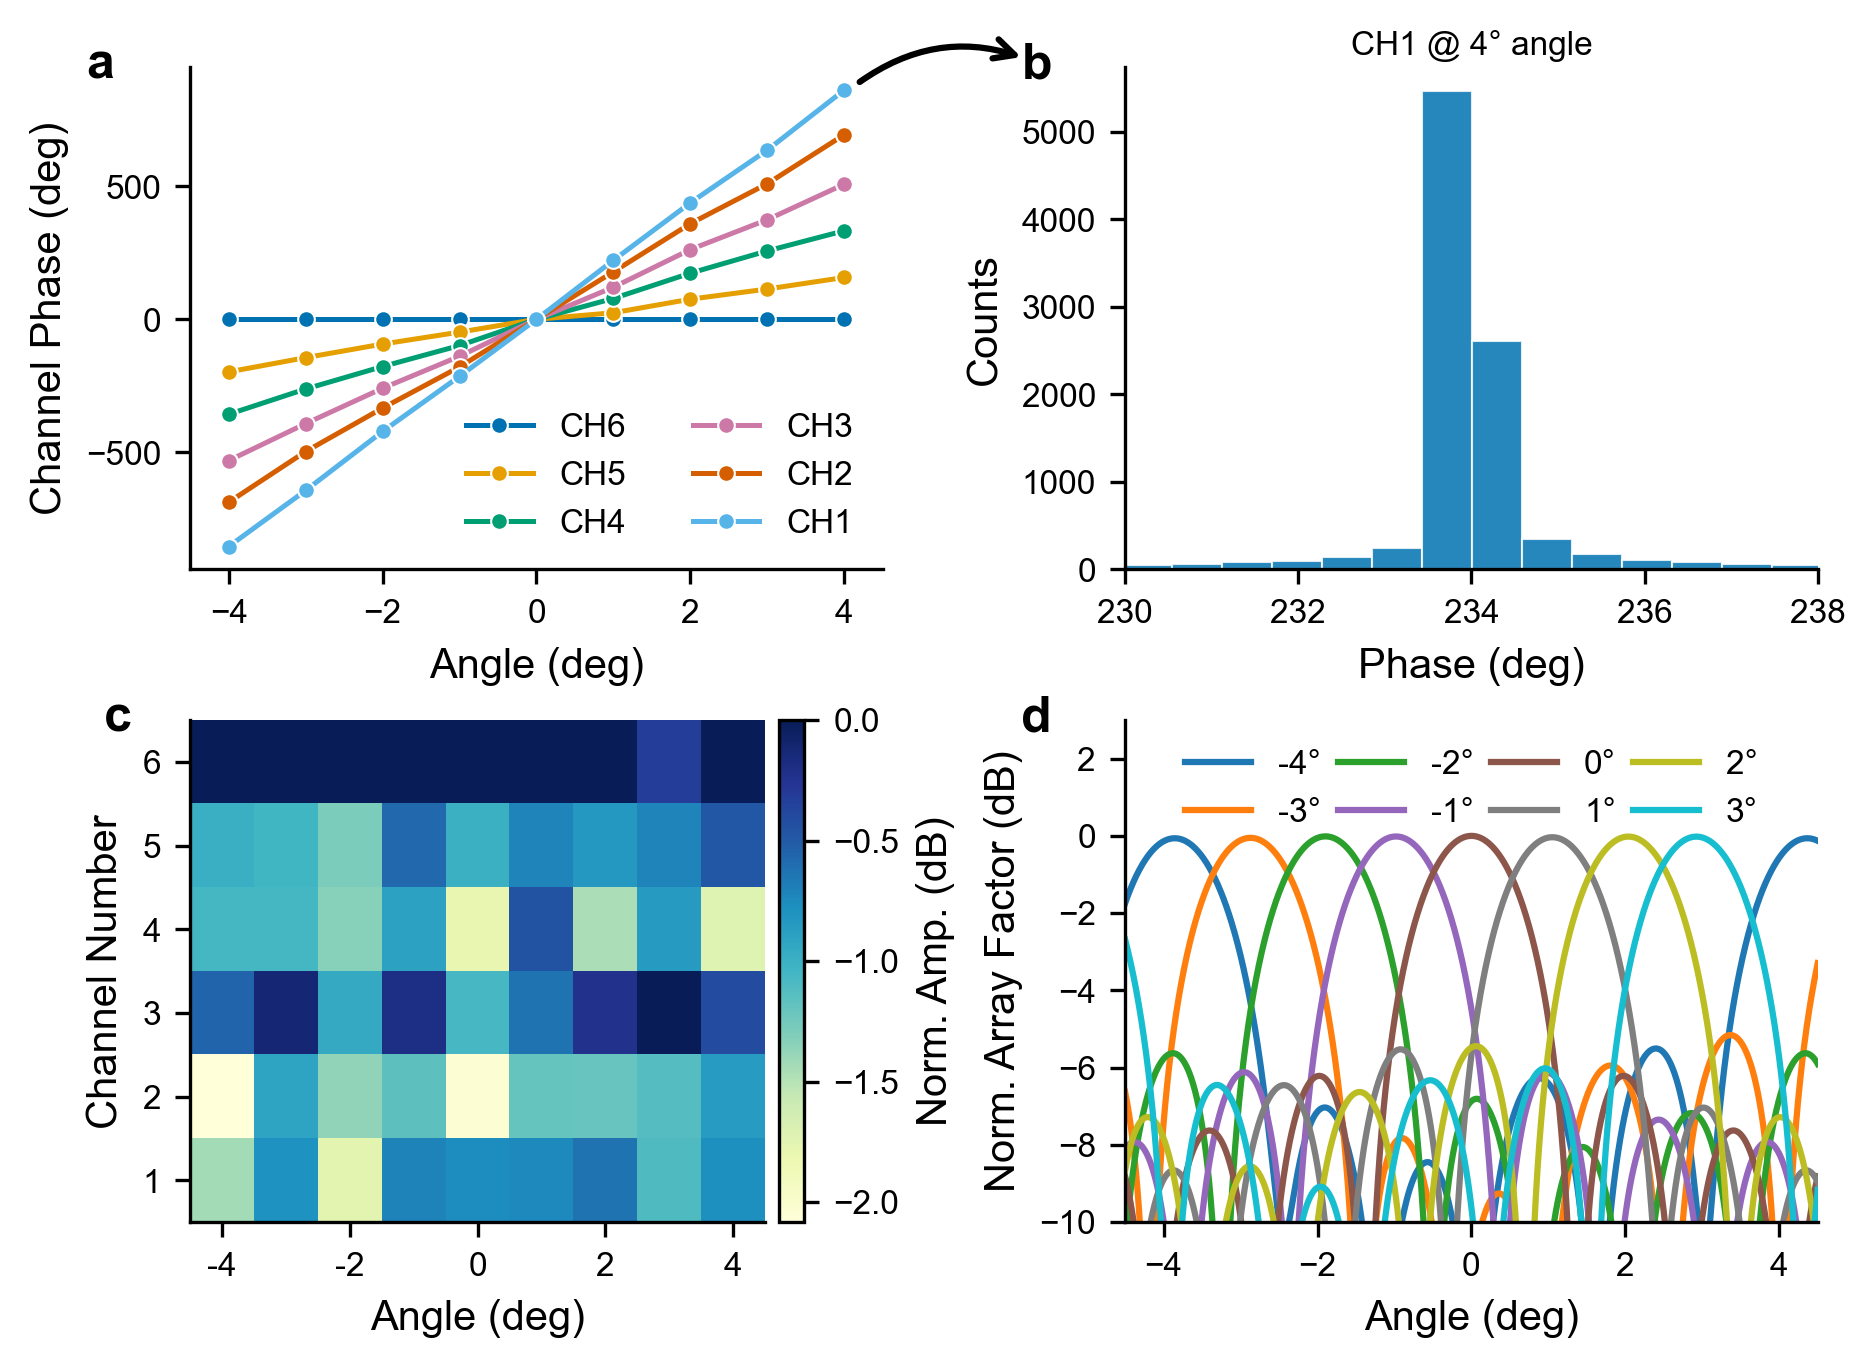

Figure saved as 'Figure4_Nature.pdf' and 'Figure4_Nature.png'


In [140]:
# Nature-style 2x2 Figure
import matplotlib as mpl
from matplotlib.patches import FancyArrowPatch, ConnectionPatch

# Font size variable - change this to adjust all text sizes
FONTSIZE = 8
LABEL_FONTSIZE = 12  # Panel labels (a, b, c, d)
AXIS_LABEL_FONTSIZE = 10  # X and Y axis labels

# Nature-style settings
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'font.size': FONTSIZE,
    'axes.linewidth': 0.8,
    'axes.labelsize': AXIS_LABEL_FONTSIZE,
    'axes.titlesize': FONTSIZE,
    'xtick.labelsize': FONTSIZE,
    'ytick.labelsize': FONTSIZE,
    'legend.fontsize': FONTSIZE,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Nature-like color palette
colors_nature = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#D55E00', '#56B4E9']

# Create figure - Nature typically uses 89mm (single column) or 183mm (double column)
fig = plt.figure(figsize=(7, 5))  # ~183mm wide

# Create GridSpec for better control
from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.35)

# ===== Panel (a): Channel Phases =====
ax1 = fig.add_subplot(gs[0, 0])
labels = ['CH6', 'CH5', 'CH4', 'CH3', 'CH2', 'CH1']
GC_data = [GC6, GC7, GC8, GC9, GC10, GC11]

for i, (data, label) in enumerate(zip(GC_data, labels)):
    ax1.plot(angles, data, '-o', color=colors_nature[i], linewidth=1.2, label=label, 
             markersize=4, markeredgecolor='white', markeredgewidth=0.5)

ax1.set_xlabel('Angle (deg)', fontsize=AXIS_LABEL_FONTSIZE)
ax1.set_ylabel('Channel Phase (deg)', fontsize=AXIS_LABEL_FONTSIZE)
ax1.set_xlim([-4.5, 4.5])
ax1.set_xticks(np.arange(-4, 5, 2))
ax1.legend(fontsize=FONTSIZE, loc='lower right', frameon=False, ncol=2)
ax1.text(-0.15, 1.05, 'a', transform=ax1.transAxes, fontsize=LABEL_FONTSIZE, fontweight='bold', va='top')

# ===== Panel (b): Phase Histogram =====
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(PhaseDiff_CH1, bins=40, edgecolor='white', linewidth=0.5, 
         alpha=0.85, color=colors_nature[0])
ax2.set_xlabel('Phase (deg)', fontsize=AXIS_LABEL_FONTSIZE)
ax2.set_ylabel('Counts', fontsize=AXIS_LABEL_FONTSIZE)
ax2.set_xlim([230, 238])
ax2.set_title(f'CH1 @ 4° angle', fontsize=FONTSIZE, pad=3)
ax2.text(-0.15, 1.05, 'b', transform=ax2.transAxes, fontsize=LABEL_FONTSIZE, fontweight='bold', va='top')

# ===== Panel (c): Channel Amplitudes Heatmap =====
ax3 = fig.add_subplot(gs[1, 0])
# Use only angles 0-8 (corresponding to -4 to +4 degrees) for normalization
amps_subset = amps[:9, :]  # First 9 angles (-4 to +4)
amps2 = amps_subset / np.max(amps_subset, axis=1, keepdims=True)
heatmap_data = 10 * np.log10(amps2.T)
im = ax3.imshow(heatmap_data, aspect='auto', cmap='YlGnBu', origin='lower',
                vmin=np.min(heatmap_data), vmax=np.max(heatmap_data))
cb = plt.colorbar(im, ax=ax3, shrink=1.0, pad=0.02)
cb.set_label('Norm. Amp. (dB)', fontsize=AXIS_LABEL_FONTSIZE)
cb.ax.tick_params(labelsize=FONTSIZE)
ax3.set_xlabel('Angle (deg)', fontsize=AXIS_LABEL_FONTSIZE)
ax3.set_ylabel('Channel Number', fontsize=AXIS_LABEL_FONTSIZE)
ax3.set_xlim([-0.5, 8.5])  # Show indices 0-8, corresponding to -4 to +4 degrees
ax3.set_xticks(np.arange(0, 9, 2))
ax3.set_xticklabels([f'{a-motor_angles[ref]}' for a in motor_angles[:9:2]])
ax3.set_yticks(np.arange(6))
ax3.set_yticklabels(['1', '2', '3', '4', '5', '6'])
ax3.text(-0.15, 1.05, 'c', transform=ax3.transAxes, fontsize=LABEL_FONTSIZE, fontweight='bold', va='top')

# ===== Panel (d): Reconstructed Array Pattern =====
ax4 = fig.add_subplot(gs[1, 1])

# Recalculate array factors for plotting
AFs_plot = []
legend_labels_plot = []
for ma_idx, ma in enumerate(ma_all):
    if ma >= len(ordered_ref):
        continue
    AF = np.zeros(len(thetas), dtype=complex)
    for gc_idx, gc in enumerate(gc_all):
        gc_phase = ordered_ref[ma, gc]
        effect = np.exp(1j * np.deg2rad(gc_phase)) * np.exp(1j * gc_idx * kd * np.sin(np.deg2rad(thetas)))
        AF = AF + effect
    AFs_plot.append(AF)
    legend_labels_plot.append(f'{angles[ma]}°')

AFs_plot = np.array(AFs_plot)
abs_AFs_plot = np.abs(AFs_plot)
norm_AFs_plot = abs_AFs_plot / np.max(abs_AFs_plot)
log_AFs_plot = 10 * np.log10(norm_AFs_plot)

# Use tab10 colormap for the different angles
cmap = plt.cm.tab10
norm = mpl.colors.Normalize(vmin=0, vmax=len(AFs_plot)-1)

for ma_idx in range(len(AFs_plot)):
    color = cmap(norm(ma_idx))
    ax4.plot(thetas, log_AFs_plot[ma_idx, :], linewidth=1.5, color=color, 
             label=legend_labels_plot[ma_idx])

ax4.set_xlim([-4.5, 4.5])
ax4.set_ylim([-10, 3])
ax4.set_xlabel('Angle (deg)', fontsize=AXIS_LABEL_FONTSIZE)
ax4.set_ylabel('Norm. Array Factor (dB)', fontsize=AXIS_LABEL_FONTSIZE)
ax4.set_xticks(np.arange(-4, 5, 2))
ax4.legend(fontsize=FONTSIZE, loc='upper center', frameon=False, ncol=4, columnspacing=0.5)
ax4.text(-0.15, 1.05, 'd', transform=ax4.transAxes, fontsize=LABEL_FONTSIZE, fontweight='bold', va='top')

# Add curved arrow from CH1 at 4° in panel (a) to panel (b) label
# CH1 is GC11 (index 5), angle 4° is the last point (index 8)
ch1_x = 4  # angle
ch1_y = GC11[8]  # phase value at angle 4°

# Draw arrow after tight_layout is applied
plt.tight_layout()

# Now add the arrow with gap from 'b' label
arrow = ConnectionPatch(
    xyA=(4.2, ch1_y + 30), coordsA=ax1.transData,    # Start near CH1 marker with gap
    xyB=(-0.15, 1.02), coordsB=ax2.transAxes,          # End just to the right of 'b' label  
    arrowstyle='->', connectionstyle='arc3,rad=-0.25',
    color='black', linewidth=1.5, mutation_scale=12
)
fig.add_artist(arrow)

plt.savefig('Figure 4.pdf', bbox_inches='tight', format='pdf')
# plt.savefig('Figure4_Nature.png', bbox_inches='tight', format='png', dpi=300)
plt.show()

print("Figure saved as 'Figure4_Nature.pdf' and 'Figure4_Nature.png'")